# CN3 - Wavelet Operator

In [1]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../../../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("/")[-1])

# test data directory
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset dirctory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])


from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch, WaveletOperator2D_FFT_torch
DataClass = STL_2D_FFT_Torch
WaveletOperatorClass = WaveletOperator2D_FFT_torch
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

import torch

Parent directory added to sys.path: .../STL-Dev
Dataset dirctory used: .../STL-Dev/data/test


/Users/richard/Desktop/STL/STL-Dev/STL_main/__init__.py:9: UserWarning: In development mode: Please run 'pip install -e .' in the root directory of the STL repository to properly install the package, its dependencies and enable proper version tracking.
  warnings.warn(


Working on device: mps


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

shape data = (256, 256)
shape data_full = (20, 256, 256)


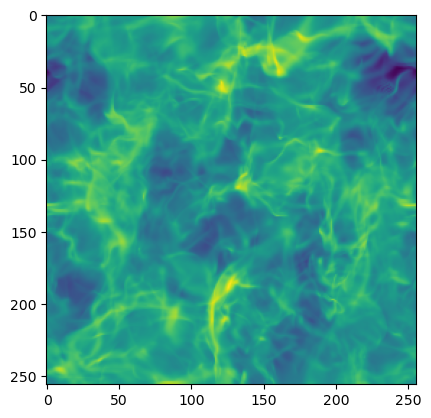

In [3]:
# Load some data
data_full = np.load(str(DATA_TEST_PATH) + "/" + "Turb_6.npy")
data = data_full[0]
print("shape data = " + str(data.shape))
print("shape data_full = " + str(data_full.shape))
plt.imshow(data)

In [4]:
# Initialization of StlData for MR=False
stl_data = DataClass(data, pbc=True)

In [5]:
# Construct the wavelet operator
Wave_Op = stl_data.get_wavelet_op(WType="Bump-Steerable")
J = Wave_Op.J
L = Wave_Op.L
print("J =", J, ", L =", L)

J = 6 , L = 4


## Full Conv in MR=False

In [6]:
# Compute the wavelet transform
WT = Wave_Op.apply(stl_data)

In [7]:
# Test of WT parameters 
print("For stl_data:")
print(type(WT))
print("DT = " + str(WT.DT))
print("dg = " + str(WT.dg))
print("N0 = " + str(WT.N0))
print("fourier_status = " + str(WT.fourier_status))
print("Type array = " + str(type(WT.array)))
print("Size array = " + str(WT.array.shape))

For stl_data:
<class 'STL_main.STL_2D_FFT_Torch.STL_2D_FFT_Torch'>
DT = Planar2D_FFT_torch
dg = 0
N0 = torch.Size([256, 256])
fourier_status = True
Type array = <class 'torch.Tensor'>
Size array = torch.Size([6, 4, 256, 256])


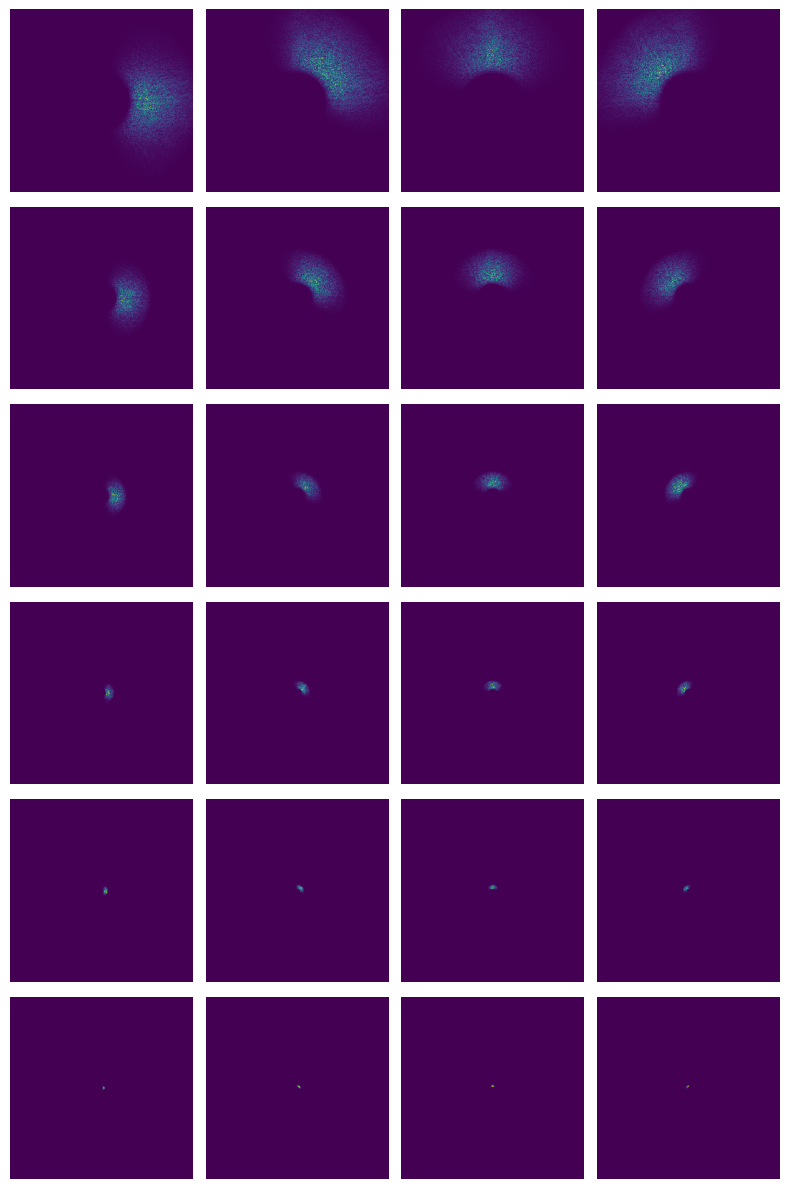

In [8]:
# Plot in Fourier space
WT.set_fourier_status(True)

# Plot the wavelet transform
fig, axs = plt.subplots(J, L, figsize=(2 * L, 2 * J))
axs = axs.reshape(J, L)

for j in range(J):
    for l in range(L):
        ax = axs[j, l]
        ax.imshow(torch.fft.fftshift(WT.array[j, l]).abs().cpu().numpy())
        ax.axis('off')

plt.tight_layout()
plt.show()

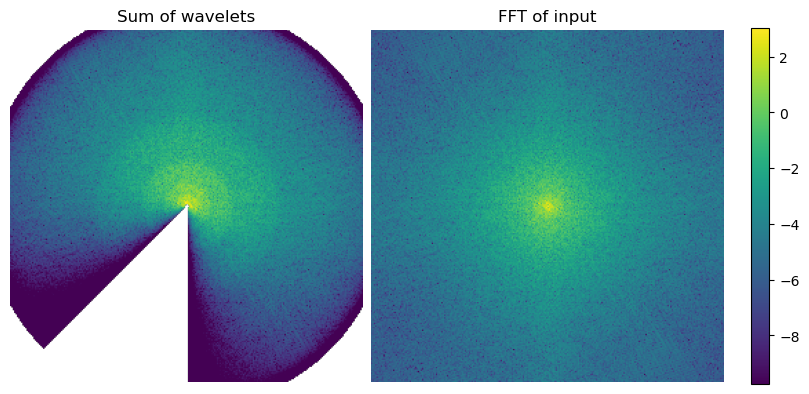

In [9]:
# Compare the abs of the Fourier Transform of data and of the sum of the convolved fields
# Note that doing Fourier -> real -> Fourier duplicates the Fourier support of the wavelets (k -> -k)
WT.set_fourier_status(True, inplace=True) 
stl_data.set_fourier_status(True, inplace=True)

# Compute the images
img1 = torch.fft.fftshift(torch.log(WT.array.abs().sum(dim=(0,1))), dim=(-2,-1)).cpu().numpy()
img2 = torch.fft.fftshift(torch.log(stl_data.array.abs()), dim=(-2,-1)).cpu().numpy()

# Compute global vmin and vmax for consistent color scale
vmin = max(np.nanmin(img1), np.nanmin(img2))
vmax = min(np.nanmax(img1), np.nanmax(img2))

# Plot
fig, axs = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

im1 = axs[0].imshow(img1, vmin=vmin, vmax=vmax)
axs[0].set_title('Sum of wavelets')
axs[0].axis('off')

im2 = axs[1].imshow(img2, vmin=vmin, vmax=vmax)
axs[1].set_title('FFT of input')
axs[1].axis('off')

# Add a single shared colorbar
fig.colorbar(im1, ax=axs, orientation='vertical', fraction=0.025, pad=0.04)
plt.show()

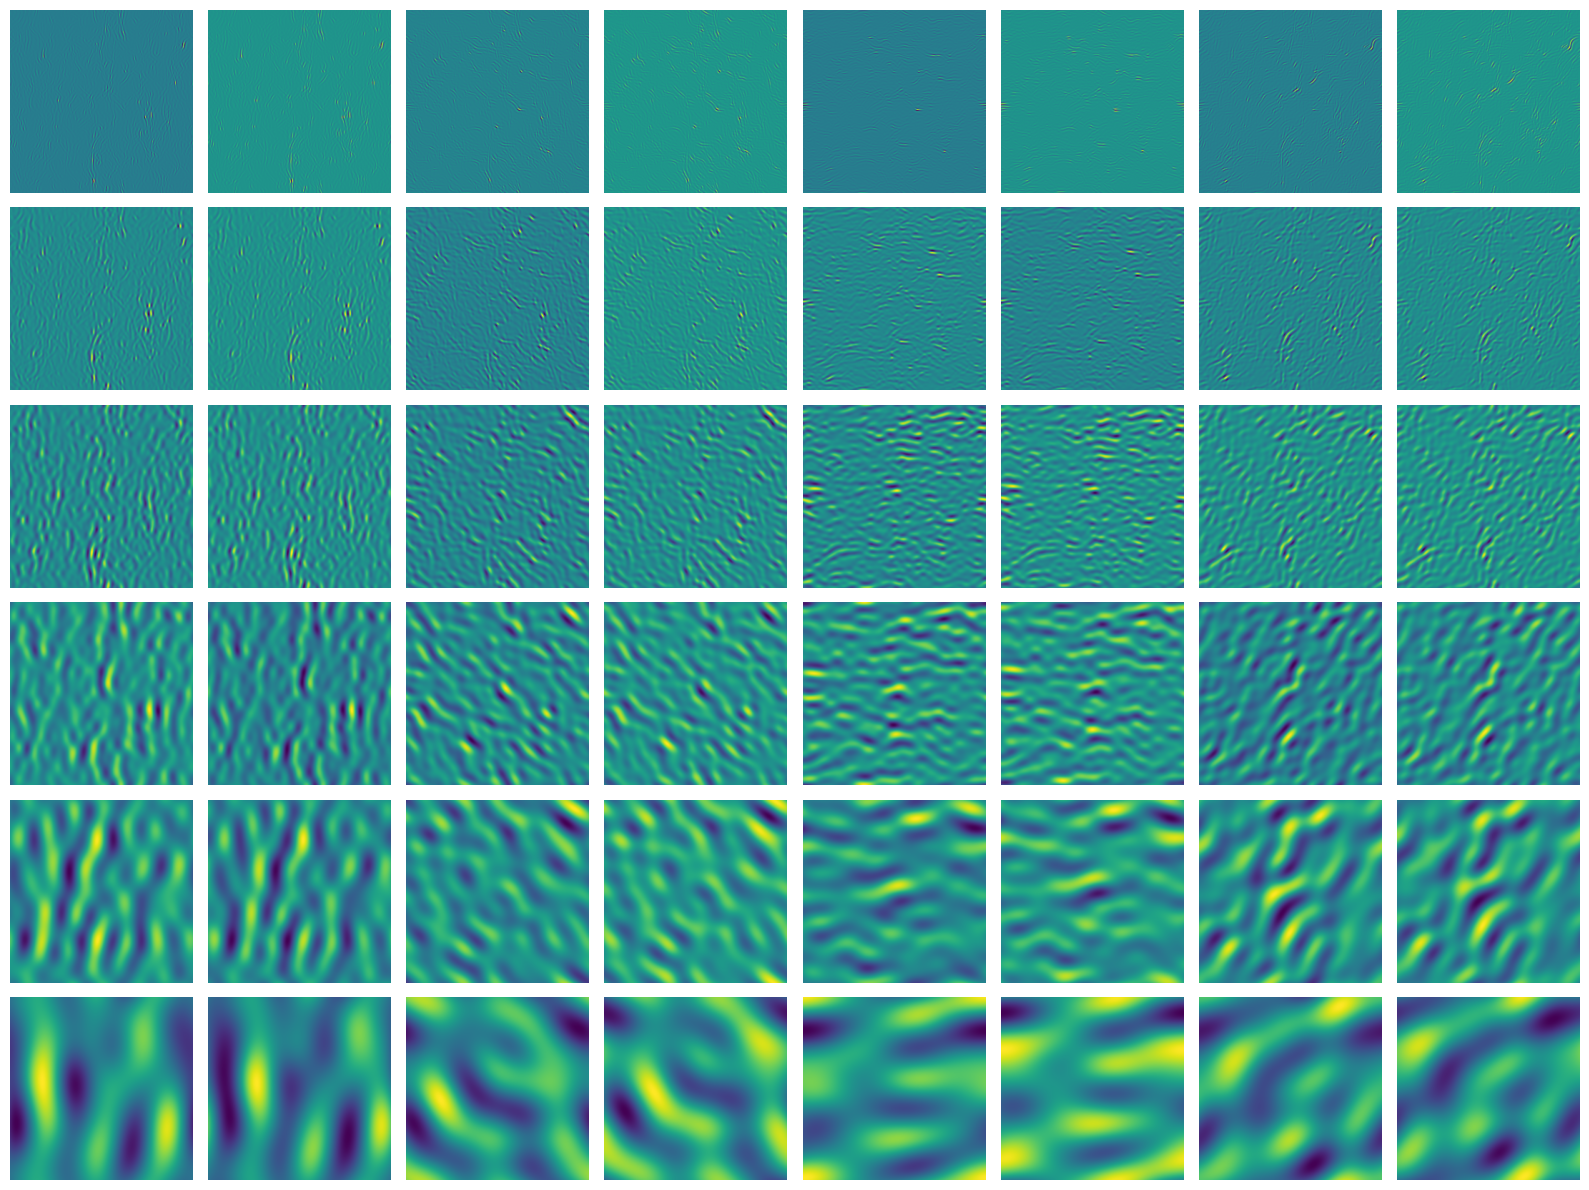

In [10]:
# Plot in real space
WT.set_fourier_status(False, inplace=True)

# Plot the real and imaginary parts of the wavelet transform
fig, axs = plt.subplots(J, 2 * L, figsize=(4 * L, 2 * J))
axs = axs.reshape(J, 2*L)

for j in range(J):
    for l in range(L):
        ax = axs[j, 2*l]
        ax.imshow(WT.array[j, l].cpu().real) # real part
        ax.axis('off')
        ax = axs[j, 2*l+1]
        ax.imshow(WT.array[j, l].cpu().imag) # imaginary part
        ax.axis('off')
plt.tight_layout()
plt.show()

## Scale by scale convolution in MR=True

In [11]:
# Create MR data
stl_data_Nj = Wave_Op.downsample(stl_data, dg_out=j-1, inplace=False)
print("For stl_data_Nj:")
print("DT = " + str(stl_data_Nj.DT))
print("dg = " + str(stl_data_Nj.dg))
print("N0 = " + str(stl_data_Nj.N0))
print("fourier_status = " + str(stl_data_Nj.fourier_status))
print("Type array = " + str(type(stl_data_Nj.array)))
print("Size array = " + str(stl_data_Nj.array.shape))

For stl_data_Nj:
DT = Planar2D_FFT_torch
dg = 4
N0 = torch.Size([256, 256])
fourier_status = True
Type array = <class 'torch.Tensor'>
Size array = torch.Size([16, 16])


In [12]:
print(stl_data_Nj.dg)
print(j)

4
5


In [13]:
# Compute the wavelet transform at scale j
WT_j = Wave_Op.apply(stl_data_Nj, j=j)
print("For WT_j:")
print("DT = " + str(WT_j.DT))
print("dg = " + str(WT_j.dg))
print("N0 = " + str(WT_j.N0))
print("fourier_status = " + str(WT_j.fourier_status))
print("Type array = " + str(type(WT_j.array)))
print("Size array = " + str(WT_j.array.shape))

For WT_j:
DT = Planar2D_FFT_torch
dg = 4
N0 = torch.Size([256, 256])
fourier_status = True
Type array = <class 'torch.Tensor'>
Size array = torch.Size([4, 16, 16])


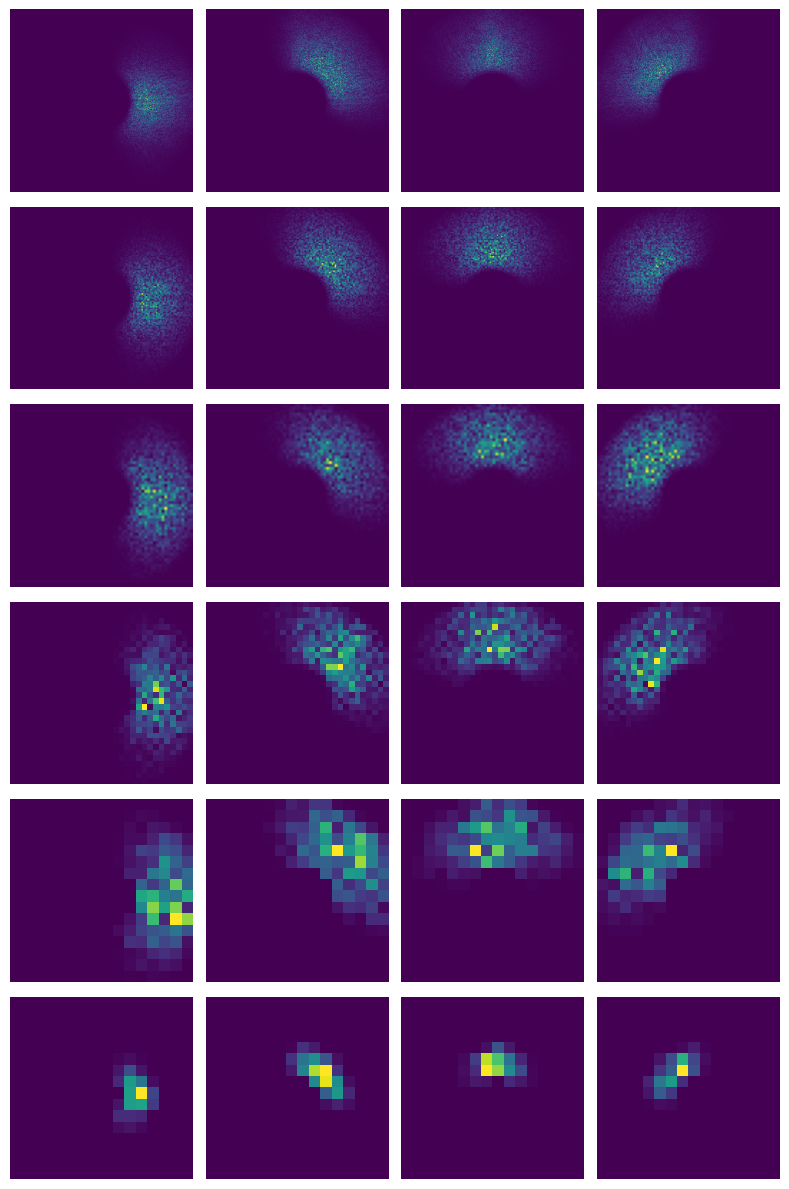

In [14]:
# Plot in Fourier space
fig, axs = plt.subplots(J, L, figsize=(2 * L, 2 * J))
axs = axs.reshape(J, L)

for j in range(J):
    stl_data_Nj = Wave_Op.downsample(stl_data, dg_out=Wave_Op.j_to_dg[j], inplace=False)
    WT_j = Wave_Op.apply(stl_data_Nj, j=j)
    for l in range(L):
        ax = axs[j, l]
        ax.imshow(torch.fft.fftshift(WT_j.array[l].abs(), dim=(-2,-1)).cpu())
        ax.axis('off')

plt.tight_layout()
plt.show()

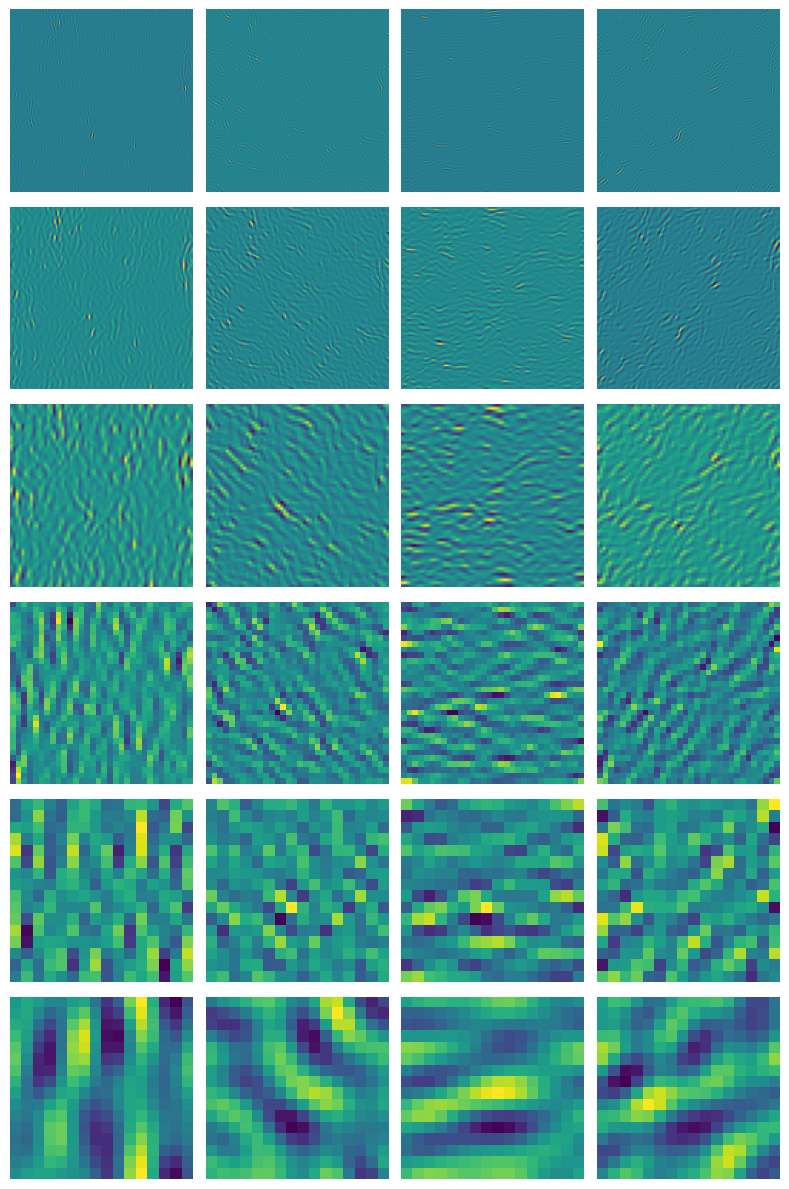

In [15]:
# Plot in real space
fig, axs = plt.subplots(J, L, figsize=(2 * L, 2 * J))
axs = axs.reshape(J, L)

for j in range(J):
    stl_data_Nj = Wave_Op.downsample(stl_data, dg_out=Wave_Op.j_to_dg[j], inplace=False)
    WT_j = Wave_Op.apply(stl_data_Nj, j=j)
    WT_j.set_fourier_status(target_fourier_status=False, inplace=True)
    for l in range(L):
        ax = axs[j, l]
        ax.imshow(torch.fft.fftshift(WT_j.array[l].real, dim=(-2,-1)).cpu())
        ax.axis('off')

plt.tight_layout()
plt.show()

## Full Conv in MR=True with non-standard sizes

In [16]:
# Initialization of StlData for MR=False
stl_data2 = DataClass(data[:187, :249])

# Construct the wavelet operator
Wave_Op2 = stl_data2.get_wavelet_op()
J2 = Wave_Op2.J

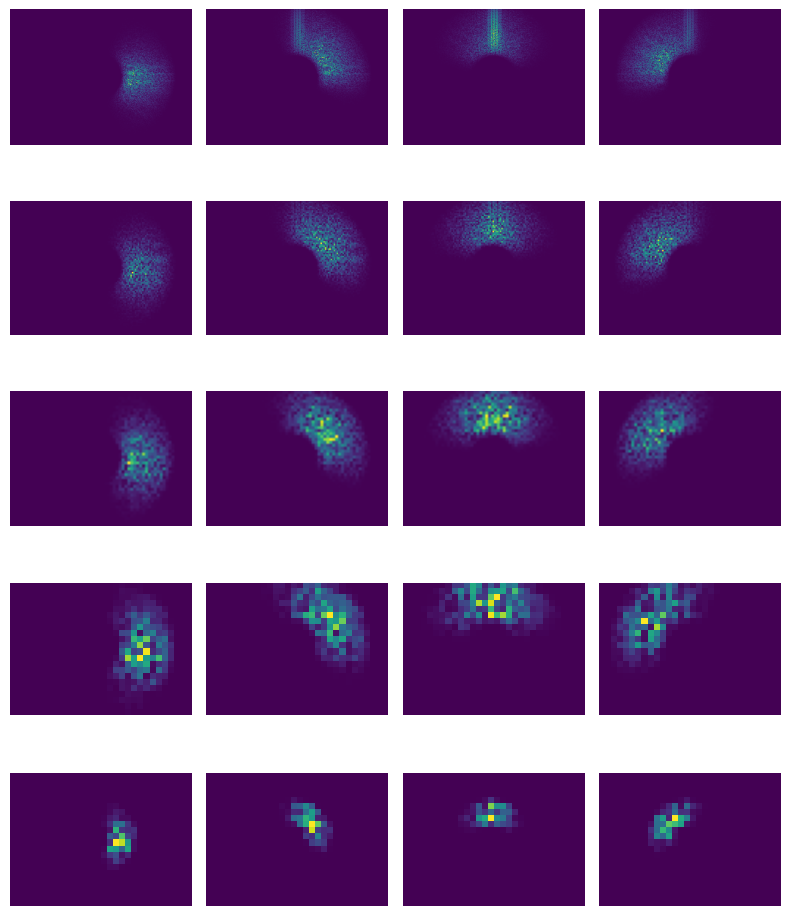

In [17]:
# Plot the wavelet transform
fig, axs = plt.subplots(J2, L, figsize=(2 * L, 2 * J2))
axs = axs.reshape(J2, L)

for j in range(J2):
    stl_data_Nj = Wave_Op2.downsample(stl_data2, dg_out=Wave_Op2.j_to_dg[j], inplace=False)
    WT_j = Wave_Op2.apply(stl_data_Nj, j=j)
    for l in range(L):
        ax = axs[j, l]
        ax.imshow(torch.fft.fftshift(WT_j.array[l].abs(), dim=(-2,-1)).cpu())
        ax.axis('off')

plt.tight_layout()
plt.show()

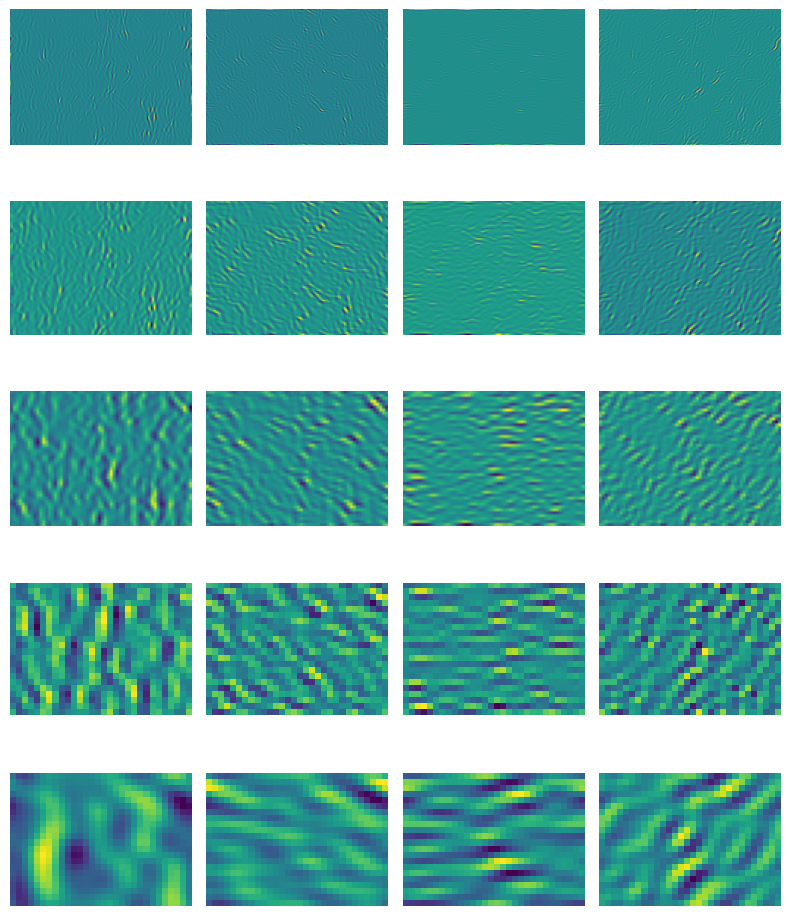

In [18]:
# Plot the wavelet transform
fig, axs = plt.subplots(J2, L, figsize=(2 * L, 2 * J2))
axs = axs.reshape(J2, L)

for j in range(J2):
    stl_data_Nj = Wave_Op2.downsample(stl_data2, dg_out=Wave_Op2.j_to_dg[j], inplace=False)
    WT_j = Wave_Op2.apply(stl_data_Nj, j=j)
    WT_j.set_fourier_status(target_fourier_status=False, inplace=True)
    for l in range(L):
        ax = axs[j, l]
        ax.imshow(WT_j.array[l].cpu().real)
        ax.axis('off')

plt.tight_layout()
plt.show()

### Standardization Criterion

White Noise PSD 

In [19]:
#  Let's check a white noise keep a PSD equal to one regardless of the image resolution dg
white_noise = torch.randn(1024, 1024, dtype=torch.float64)
white_noise_data = DataClass(white_noise, pbc=True)
white_noise_op = white_noise_data.get_wavelet_op()

/Users/richard/miniconda3/envs/gpu310/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/richard/miniconda3/envs/gpu310/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


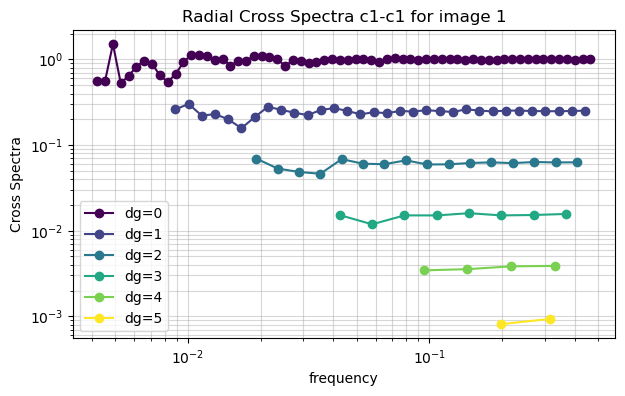

In [20]:
plt.figure(figsize=(7,4))

colors = plt.cm.viridis(np.linspace(0, 1, 6))

for dg in range(6):

    white_noise_data_dg = WaveletOperatorClass.downsample(
                                                data=white_noise_data, 
                                                dg_out=dg, 
                                                inplace=False,
                                                target_fourier_status=True
                                                )
    
    white_noise_data.pbc = True
    white_noise_data_dg.N0 = white_noise_data_dg.array.shape[-2:]
    white_noise_data_dg.dg = 0

    ps_op_dg = white_noise_data_dg.get_CS_op()
    ps_tensor_dg = ps_op_dg.apply(white_noise_data_dg)

    ps_op_dg.plot_cross_spectrum(ps_tensor_dg, label=f"dg={dg}", color=colors[dg])

Littlewood Plaley

In [21]:
stl_data.set_fourier_status(True, inplace=True)
Wave_Op = stl_data.get_wavelet_op()

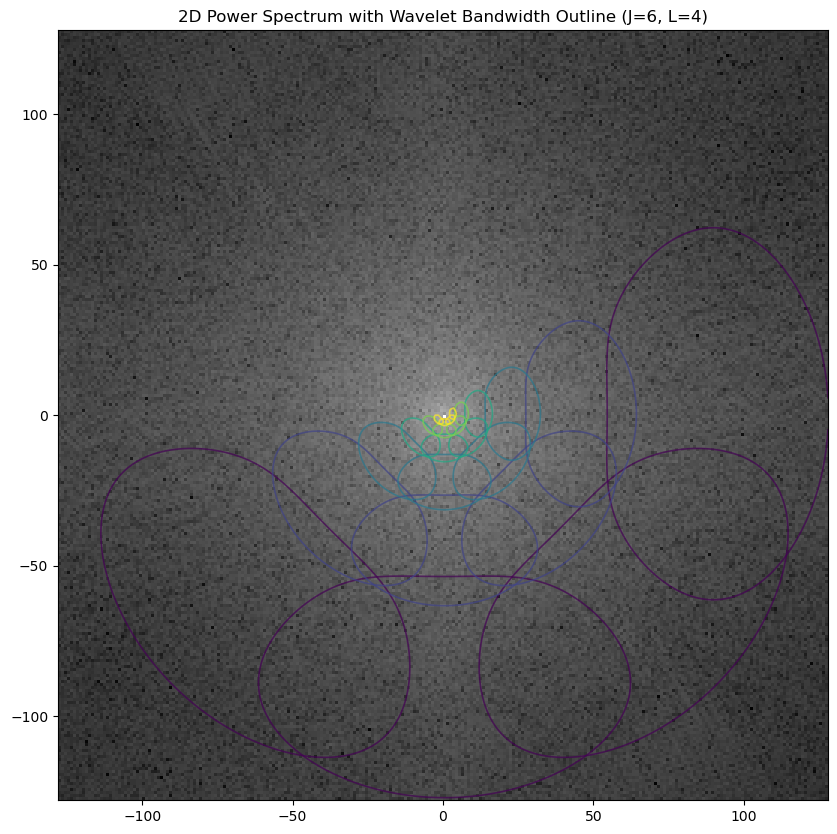

In [22]:
power_spectrum_2d = torch.fft.fftshift(stl_data.array).abs()**2

plt.figure(figsize=(12, 10))

plt.imshow(torch.log(power_spectrum_2d).cpu().numpy(), cmap='gray', extent=[-stl_data.N0[0]//2, stl_data.N0[0]//2, -stl_data.N0[1]//2, stl_data.N0[1]//2])
colors = plt.cm.viridis(np.linspace(0, 1, Wave_Op.J))

for j in range(Wave_Op.J):
    for l in range(Wave_Op.L):

        wav = torch.fft.fftshift(Wave_Op.wavelet_array[j, l], dim=(-2,-1))
        wav = wav.cpu().numpy()

        plt.contour(wav, levels=[0.5*wav.max()], 
                    colors=[colors[j]], 
                    extent=[-stl_data.N0[0]//2, stl_data.N0[0]//2, -stl_data.N0[1]//2, stl_data.N0[1]//2],
                    linewidths=1.2, alpha=0.7)
        
plt.title(f"2D Power Spectrum with Wavelet Bandwidth Outline (J={Wave_Op.J}, L={Wave_Op.L})")
plt.show()

To verify Littlewood-Paley's condition, the following property should be respected

$$
\sum_{j, \theta} \left| \hat{\psi}_{j, \theta}(\mathbf{\omega}) \right|^2 = 1, \quad \forall \mathbf{\omega}
$$


Text(0.5, 1.0, 'Energy Recovery Ratio in Fourier Space')

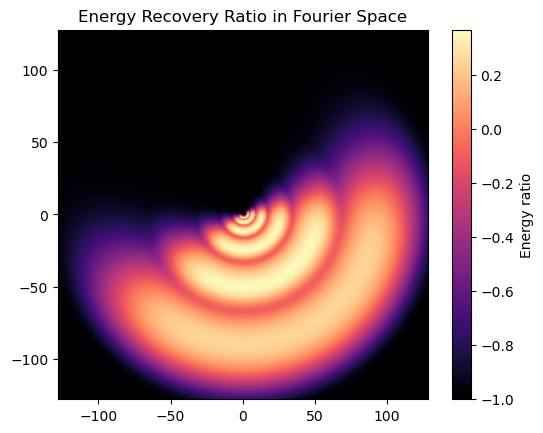

In [23]:
energy_recovery = torch.zeros_like(power_spectrum_2d)

for j in range(Wave_Op.J):
    for l in range(Wave_Op.L):
        wav = torch.fft.fftshift(Wave_Op.wavelet_array[j, l], dim=(-2,-1))

        energy_recovery += wav.abs()**2

plt.imshow(
    (energy_recovery-1).cpu().numpy(),
    origin='lower',
    cmap='magma',
    extent=[-stl_data.N0[0]//2, stl_data.N0[0]//2, -stl_data.N0[1]//2, stl_data.N0[1]//2],
)
plt.colorbar(label="Energy ratio")
plt.title("Energy Recovery Ratio in Fourier Space")


Final test - Image energy recovery from S2 coefficients

In [24]:
stl_op = white_noise_data.get_ST_op()
stl_stats = stl_op.apply(white_noise_data, norm="vanilla")

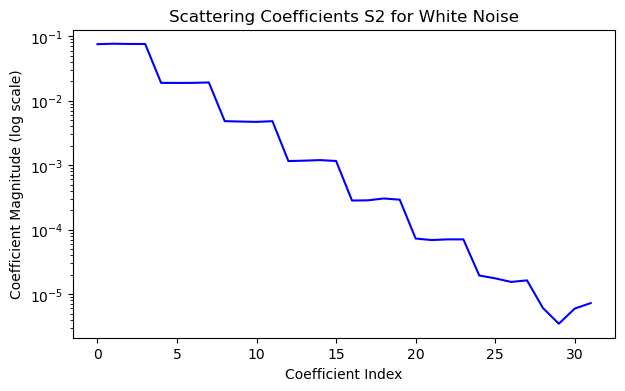

In [25]:
plt.figure(figsize=(7,4))
plt.plot(stl_stats.S2.abs().cpu().numpy().flatten(),color='b')
plt.title("Scattering Coefficients S2 for White Noise")
plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Magnitude (log scale)")
plt.yscale('log')
plt.show()